# RQ6 Extended - Multi-Dataset Validation (Separate + Combined)

Tests model generalization across:
- **HAM10000** (internal, training baseline)
- **ISIC2020** (external A, same dermoscopy, 33K images)
- **MILK10K** (external B, diverse ethnicity, mixed modalities)
- **Malignant-Benign** (external C, varied sources)
- **PH2** (external D, dermoscopy)

Each dataset tested **separately** (train/test split within dataset) and **combined** (all external pooled).

In [1]:
import os, sys
from pathlib import Path

NOTEBOOK_DIR = Path(os.getcwd()).resolve()
BACKEND_DIR = Path(os.environ.get(
    "SKIN_LESION_BACKEND_DIR",
    NOTEBOOK_DIR.parent.parent / "Skin_Lesion_Classification_backend"
))
ML_DIR = BACKEND_DIR / "ml"
if str(ML_DIR) not in sys.path:
    sys.path.insert(0, str(ML_DIR))

RAW_DIR = ML_DIR / "data" / "processed" / "raw"
OUT = NOTEBOOK_DIR / "outputs"
(OUT / "figures").mkdir(parents=True, exist_ok=True)
(OUT / "metrics").mkdir(exist_ok=True)

print(f"Notebook: {NOTEBOOK_DIR.name}")
print(f"Backend:  {BACKEND_DIR.name}")
print(f"Raw data: {RAW_DIR}")

Notebook: notebooks
Backend:  Skin_Lesion_Classification_backend
Raw data: C:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_backend\ml\data\processed\raw


---

## CELL 2: Scan All Dataset Folders

Build metadata dataframes for each dataset.

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image

RAW = RAW_DIR  # shorthand

def scan_isic2020():
    """Scan ISIC2020 Training JPEG folder."""
    train_dir = RAW / "isic2020" / "ISIC_2020_Training_JPEG" / "train"
    meta_path = RAW / "isic2020" / "ISIC_2020_Training_MetaData.csv"
    meta = pd.read_csv(meta_path)
    
    # Build filepath column
    meta["filepath"] = meta["image_name"].apply(lambda x: str(train_dir / f"{x}.jpg"))
    
    # Verify files exist
    meta["exists"] = meta["filepath"].apply(lambda p: Path(p).exists())
    print(f"ISIC2020: {meta['exists'].sum()}/{len(meta)} files found")
    
    # Filter to only existing
    meta = meta[meta["exists"]].copy()
    
    # Binary label
    meta["true_label"] = meta["target"].astype(int)
    meta["diagnosis"] = meta["benign_malignant"]
    
    return meta[["image_name", "filepath", "true_label", "diagnosis", 
                 "patient_id", "sex", "age_approx", "anatom_site_general_challenge"]]

def scan_milk10k():
    """Scan MILK10K dataset."""
    meta_path = RAW / "milk10k" / "metadata.csv"
    img_dir = RAW / "milk10k" / "images"
    meta = pd.read_csv(meta_path)
    
    # Build filepath
    meta["filepath"] = meta["isic_id"].apply(lambda x: str(img_dir / f"{x}.jpg"))
    meta["exists"] = meta["filepath"].apply(lambda p: Path(p).exists())
    print(f"MILK10K: {meta['exists'].sum()}/{len(meta)} files found")
    
    # Binary label: Malignant=1, Benign=0
    meta["true_label"] = meta["diagnosis_1"].apply(
        lambda x: 1 if str(x).lower() == "malignant" else (0 if "benign" in str(x).lower() else -1)
    )
    # Filter valid labels only
    meta = meta[meta["true_label"].isin([0, 1])].copy()
    
    return meta[["isic_id", "filepath", "true_label", "diagnosis_1",
                 "image_type", "sex", "age_approx", "anatom_site_general"]]

def scan_ham10000():
    """Load existing HAM10000 metadata and normalize to the RQ6 schema."""
    meta_path = ML_DIR / "data" / "processed" / "metadata_with_paths.csv"
    if meta_path.exists():
        meta = pd.read_csv(meta_path)
        if "true_label" not in meta.columns:
            if "label" in meta.columns:
                meta["true_label"] = meta["label"].astype(int)
            elif "dx" in meta.columns:
                dx_map = {"nv": 0, "bkl": 0, "akiec": 0, "bcc": 0, "df": 0, "vasc": 0, "mel": 1}
                meta["true_label"] = meta["dx"].map(dx_map).astype(int)
            else:
                raise KeyError("HAM10000 metadata needs label, true_label, or dx column")
        if "diagnosis" not in meta.columns:
            meta["diagnosis"] = meta["dx"] if "dx" in meta.columns else "unknown"
        if "image_id" not in meta.columns:
            meta["image_id"] = meta.index.astype(str)
        meta = meta[meta["true_label"].isin([0, 1])].copy()
        print(f"HAM10000: {len(meta)} images")
        return meta
    # Fallback
    img_dir = RAW / "images"
    meta_csv = RAW / "HAM10000_metadata.csv"
    meta = pd.read_csv(meta_csv)
    meta["filepath"] = meta["image_id"].apply(lambda x: str(img_dir / f"{x}.jpg"))
    meta["exists"] = meta["filepath"].apply(lambda p: Path(p).exists())
    meta = meta[meta["exists"]].copy()
    dx_map = {"nv": 0, "bkl": 0, "akiec": 0, "bcc": 0, "df": 0, "vasc": 0, "mel": 1}
    meta["true_label"] = meta["dx"].map(dx_map)
    print(f"HAM10000: {len(meta)} images found")
    return meta

def scan_malignant_benign():
    """Scan Malignant-Benign kaggle dataset."""
    mb_path = Path.home() / ".cache" / "kagglehub" / "datasets" / "vivekkumar2300" / "skin-cancer-dataset-malignant-and-benign" / "versions" / "1" / "35000 Dataset"
    rows = []
    for label, label_name in [(0, "Benign"), (1, "Malignant")]:
        folder = mb_path / label_name
        if folder.exists():
            for fp in folder.glob("*.jpg"):
                rows.append({"image_id": fp.stem, "filepath": str(fp), 
                             "true_label": label, "diagnosis": label_name.lower()})
    df = pd.DataFrame(rows)
    print(f"Malignant-Benign: {len(df)} images")
    return df

def scan_ph2():
    """Scan PH2 dataset."""
    ph2_path = Path.home() / ".cache" / "kagglehub" / "datasets" / "spacesurfer" / "ph2-dataset" / "versions" / "2"
    label_path = ph2_path / "PH2Dataset" / "PH2_dataset.txt"
    if not label_path.exists():
        print("PH2 labels not found")
        return pd.DataFrame()
    ph2_df_raw = pd.read_csv(label_path, sep="|")
    ph2_labels = ph2_df_raw[ph2_df_raw["   Name "].str.contains("IMD", na=False)].copy()
    ph2_labels = ph2_labels.rename(columns={"   Name ": "image_id", " Clinical Diagnosis ": "clinical_dx"})
    ph2_labels["image_id"] = ph2_labels["image_id"].str.strip()
    ph2_labels["true_label"] = ph2_labels["clinical_dx"].map({0.0: 0, 1.0: 1, 2.0: 1})
    ph2_img_root = ph2_path / "PH2Dataset" / "PH2 Dataset images"
    rows = []
    for _, row in ph2_labels.iterrows():
        folder = ph2_img_root / row["image_id"]
        derm_path = folder / f"{row['image_id']}_Dermoscopic_Image" / f"{row['image_id']}.bmp"
        if derm_path.exists():
            rows.append({"image_id": row["image_id"], "filepath": str(derm_path),
                         "true_label": int(row["true_label"]), 
                         "diagnosis": "malignant" if row["true_label"] == 1 else "benign"})
    df = pd.DataFrame(rows)
    print(f"PH2: {len(df)} images")
    return df

print("Scanning datasets...")
ham_df     = scan_ham10000()
isic_df    = scan_isic2020()
milk_df    = scan_milk10k()
mb_df      = scan_malignant_benign()
ph2_df     = scan_ph2()

print(f"\nSummary:")
for name, df in [("HAM10000", ham_df), ("ISIC2020", isic_df), 
                  ("MILK10K", milk_df), ("Malignant-Benign", mb_df), ("PH2", ph2_df)]:
    if len(df) > 0 and "true_label" in df.columns:
        dist = df["true_label"].value_counts().to_dict()
        print(f"  {name:<20}: {len(df):>6} images | label dist: {dist}")
    else:
        print(f"  {name:<20}: NOT AVAILABLE")

Scanning datasets...
HAM10000: 10015 images
ISIC2020: 33126/33126 files found
MILK10K: 10480/10480 files found
Malignant-Benign: 34992 images
PH2: 200 images

Summary:
  HAM10000            :  10015 images | label dist: {0: 8388, 1: 1627}
  ISIC2020            :  33126 images | label dist: {0: 32542, 1: 584}
  MILK10K             :  10234 images | label dist: {1: 7268, 0: 2966}
  Malignant-Benign    :  34992 images | label dist: {0: 17500, 1: 17492}
  PH2                 :    200 images | label dist: {1: 120, 0: 80}


---

## CELL 3: Load Trained Model

Uses the ResNet50 checkpoint trained on HAM10000.

In [3]:
import torch

MODEL_PATH = ML_DIR / "outputs" / "models" / "resnet50_best.pth"
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model not found at {MODEL_PATH} — run 00_setup notebook first")

from src.models.classifier import create_model, get_target_layer
from src.data.dataset import get_transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = create_model("resnet50", num_classes=1).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=False)["model_state_dict"])
model.eval()
target_layer = get_target_layer(model, "resnet50")
transform = get_transforms("test", 224)
print("Model loaded.")

c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_XAI_research\skin-lesion-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_XAI_research\skin-lesion-env\Lib\site-packages\albumentations\__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.24). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Device: cuda


KeyboardInterrupt: 

---

## CELL 4: Evaluate on Each Dataset SEPARATELY

For each dataset: split into train (80%) / test (20%) within the dataset,
evaluate, then record metrics.

This tests whether the model generalizes to unseen data within each population.

In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from tqdm import tqdm
from PIL import Image
import numpy as np

def evaluate_df(df, name, sample_n=None, seed=42, use_stratify=True):
    """Run inference on a stratified sample of df.
    
    For datasets with a sample cap, uses StratifiedShuffleSplit to preserve
    class ratios in the sample. Reports per-class metrics alongside overall AUC.
    """
    eval_df = df.copy()
    
    # Stratified sampling if sample_n is set and df is larger than sample
    if sample_n and len(eval_df) > sample_n:
        if use_stratify:
            sss = StratifiedShuffleSplit(n_splits=1, train_size=sample_n, random_state=seed)
            _, eval_idx = next(sss.split(eval_df, eval_df["true_label"]))
            eval_df = eval_df.iloc[eval_idx].reset_index(drop=True)
        else:
            eval_df = eval_df.sample(min(sample_n, len(eval_df)), random_state=seed).reset_index(drop=True)
    
    rows = []
    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc=name, leave=True):
        try:
            img = np.array(Image.open(row["filepath"]).convert("RGB").resize((224, 224)))
            inp = transform(image=img)["image"].unsqueeze(0).to(device)
            with torch.no_grad():
                out = torch.sigmoid(model(inp)[0, 0]).item()
            pred = int(out > 0.5)
            conf = out if pred == 1 else 1 - out
            rows.append({
                "image_id": row.get("image_id") or row.get("image_name") or row.get("isic_id"),
                "filepath": row["filepath"],
                "true_label": row["true_label"],
                "pred": pred,
                "confidence": conf,
                "malignant_prob": out,
                "correct": int(pred == row["true_label"]),
                "dataset": name,
            })
        except Exception as e:
            print(f"  ERROR on {row.get('image_id','?')}: {e}")
    
    result_df = pd.DataFrame(rows)
    
    # Per-class breakdown
    print(f"  [{name}] Per-class actual distribution in evaluated sample:")
    for label, label_name in [(0, "Benign"), (1, "Malignant")]:
        sub = result_df[result_df["true_label"] == label]
        if len(sub) > 0:
            cls_acc = sub["correct"].mean()
            cls_conf = sub["confidence"].mean()
            n_correct = sub["correct"].sum()
            print(f"    {label_name:<12}: n={len(sub):>4}, acc={cls_acc:.4f}, avg_conf={cls_conf:.4f}, correct={n_correct}")
    
    return result_df

# Datasets to evaluate (use sample for large datasets)
dataset_configs = {
    "HAM10000": {"df": ham_df, "sample": None},        # full HAM10000
    "ISIC2020": {"df": isic_df, "sample": 2000},      # stratified sample 2000
    "MILK10K": {"df": milk_df, "sample": 2000},      # stratified sample 2000
    "Malignant-Benign": {"df": mb_df, "sample": 1000},  # stratified sample 1000
    "PH2": {"df": ph2_df, "sample": None},           # full PH2 (200 images)
}

all_results = {}
print("Evaluating each dataset separately (stratified sampling)...\n")
for name, cfg in dataset_configs.items():
    if len(cfg["df"]) == 0:
        print(f"[{name}] SKIPPED — no data")
        continue
    print(f"\n[{name}] {len(cfg['df'])} images, sample={cfg['sample']}")
    res = evaluate_df(cfg["df"], name, sample_n=cfg["sample"])
    auc = roc_auc_score(res["true_label"], res["malignant_prob"]) if res["true_label"].nunique() > 1 else float("nan")
    acc = accuracy_score(res["true_label"], res["pred"])
    conf = res["confidence"].mean()
    print(f"  Overall → AUC={auc:.4f}  Acc={acc:.4f}  Conf={conf:.4f}  (n={len(res)})")
    all_results[name] = res

print(f"\nDatasets evaluated: {list(all_results.keys())}")

In [ ]:
# Investigate class distribution BEFORE sampling
print("=" * 70)
print("CLASS DISTRIBUTION ANALYSIS — Before Sampling")
print("=" * 70)
print(f"{'Dataset':<22} {'Total':>7} {'Benign':>8} {'Malignant':>10} {'Mal %':>8}")
print("-" * 70)

class_dist = {}
for name, cfg in dataset_configs.items():
    df = cfg["df"]
    if len(df) == 0:
        print(f"{name:<22} {'N/A':>7}")
        continue
    n_total = len(df)
    n_benign = (df["true_label"] == 0).sum()
    n_mal = (df["true_label"] == 1).sum()
    mal_pct = n_mal / n_total * 100
    print(f"{name:<22} {n_total:>7} {n_benign:>8} {n_mal:>10} {mal_pct:>7.1f}%")
    class_dist[name] = {"total": n_total, "benign": int(n_benign), "malignant": int(n_mal), "mal_pct": mal_pct}

print("=" * 70)

# Update sampling to use stratified approach
# For each dataset with a sample cap, compute how many per class to sample
print("\nSTRATIFIED SAMPLING PLAN (preserving class ratios):")
print("-" * 50)
for name, cfg in dataset_configs.items():
    df = cfg["df"]
    sample_n = cfg["sample"]
    if sample_n is None or len(df) <= sample_n:
        print(f"  {name:<22}: Full dataset ({len(df)} images) — no sampling")
        cfg["stratified_sample"] = None
        continue
    
    # Compute stratified sample
    mal_ratio = (df["true_label"] == 1).mean()
    n_mal_sample = int(sample_n * mal_ratio)
    n_ben_sample = sample_n - n_mal_sample
    print(f"  {name:<22}: Sample {sample_n} → {n_mal_sample} malignant + {n_ben_sample} benign (mal_ratio={mal_ratio:.3f})")
    cfg["stratified_sample"] = sample_n  # still use overall sample_n, we just track ratios

print("\nNote: Actual sampling in evaluate_df is still random. For strict stratification,")
print("      use sklearn.model_selection.StratifiedShuffleSplit instead.")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Baseline (HAM10000)
ham_auc = roc_auc_score(all_results["HAM10000"]["true_label"], all_results["HAM10000"]["malignant_prob"])
ham_acc = accuracy_score(all_results["HAM10000"]["true_label"], all_results["HAM10000"]["pred"])

print("=" * 80)
print("TABLE 1 — WITHIN-DATASET EVALUATION (Stratified Sampling Per Dataset)")
print("=" * 80)
print(f"{'Dataset':<22} {'N':>6} {'AUC':>8} {'Acc':>8} {'Conf':>8} {'AUC Drop':>10} {'Benign Acc':>11} {'Mal Acc':>8}")
print("-" * 80)

perf_rows = []
for name, res in all_results.items():
    auc = roc_auc_score(res["true_label"], res["malignant_prob"]) if res["true_label"].nunique() > 1 else float("nan")
    acc = accuracy_score(res["true_label"], res["pred"])
    conf = res["confidence"].mean()
    drop = ham_auc - auc if not np.isnan(auc) else float("nan")
    
    # Per-class accuracy
    benign_sub = res[res["true_label"] == 0]
    mal_sub = res[res["true_label"] == 1]
    benign_acc = accuracy_score(benign_sub["true_label"], benign_sub["pred"]) if len(benign_sub) > 0 else float("nan")
    mal_acc = accuracy_score(mal_sub["true_label"], mal_sub["pred"]) if len(mal_sub) > 0 else float("nan")
    
    print(f"{name:<22} {len(res):>6} {auc:>8.4f} {acc:>8.4f} {conf:>8.4f} {drop:>+10.4f} {benign_acc:>11.4f} {mal_acc:>8.4f}")
    perf_rows.append({
        "dataset": name, "n": len(res), "auc": auc, 
        "accuracy": acc, "confidence": conf, "auc_drop": drop,
        "benign_acc": benign_acc, "malignant_acc": mal_acc
    })

print("=" * 80)
print(f"\nBaseline (HAM10000): AUC={ham_auc:.4f}, Acc={ham_acc:.4f}")
print("\nNote: 'Conf' = mean prediction confidence (higher = more confident)")
print("      AUC Drop = HAM10000_AUC - Dataset_AUC (positive = degraded performance)")

# Bar chart
perf_df = pd.DataFrame(perf_rows)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

order = list(all_results.keys())
pal = ["steelblue", "coral", "seagreen", "goldenrod", "mediumpurple"]

metrics = [("auc", "AUC (higher = better)"), 
           ("accuracy", "Overall Accuracy"),
           ("benign_acc", "Benign Accuracy"),
           ("malignant_acc", "Malignant Accuracy")]

for ax, (col, title) in zip(axes.flatten(), metrics):
    bars = ax.bar(perf_df["dataset"], perf_df[col], color="steelblue", width=0.6)
    ax.axhline(y=perf_df[perf_df["dataset"]=="HAM10000"][col].values[0], 
               color="red", linestyle="--", label="HAM10000 baseline")
    ax.set_title(title)
    ax.set_ylabel(col)
    ax.tick_params(axis="x", rotation=30)
    ax.set_ylim(0, 1.05)
    for bar, val in zip(bars, perf_df[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)
    ax.legend(fontsize=8)

plt.suptitle("Within-Dataset Evaluation: All 5 Datasets (Stratified Sampling)", fontsize=12)
plt.tight_layout()
plt.savefig(OUT / "figures" / "RQ6_ext_separate_performance.png", dpi=150, bbox_inches="tight")
plt.show()

---

## CELL 6b: Evaluate on COMBINED Top-3 Dataset (ISIC2020 + HAM10000 + MILK10K)

Pool ISIC2020 + HAM10000 + MILK10K (the 3 primary dermoscopy/clinical datasets),
then evaluate together. Excludes Malignant-Benign and PH2.

In [ ]:
# Combine only ISIC2020 + HAM10000 + MILK10K (top 3 primary datasets)
combined_top3_rows = []
for name in ["ISIC2020", "HAM10000", "MILK10K"]:
    if name in all_results:
        combined_top3_rows.append(all_results[name].assign(source_dataset=name))

combined_top3_df = pd.concat(combined_top3_rows, ignore_index=True)
print(f"Combined Top-3 dataset: {len(combined_top3_df)} images")
print(f"  Source breakdown: {combined_top3_df['source_dataset'].value_counts().to_dict()}")
print(f"  Label distribution: {combined_top3_df['true_label'].value_counts().to_dict()}")

# Evaluate on combined
top3_auc = roc_auc_score(combined_top3_df["true_label"], combined_top3_df["malignant_prob"]) if combined_top3_df["true_label"].nunique() > 1 else float("nan")
top3_acc = accuracy_score(combined_top3_df["true_label"], combined_top3_df["pred"])
top3_conf = combined_top3_df["confidence"].mean()

print(f"\nCOMBINED Top-3 AUC={top3_auc:.4f}  Acc={top3_acc:.4f}  Conf={top3_conf:.4f}")
print(f"AUC drop from HAM10000 alone: {ham_auc - top3_auc:+.4f}")

# Breakdown by source dataset
print("\n--- Per-source in combined Top-3 ---")
for src in ["ISIC2020", "HAM10000", "MILK10K"]:
    sub = combined_top3_df[combined_top3_df["source_dataset"] == src]
    if len(sub) > 0:
        auc = roc_auc_score(sub["true_label"], sub["malignant_prob"]) if sub["true_label"].nunique() > 1 else float("nan")
        acc = accuracy_score(sub["true_label"], sub["pred"])
        print(f"  {src:<20}: AUC={auc:.4f}  Acc={acc:.4f}  (n={len(sub)})")

## CELL 6c: Evaluate on COMBINED Dermoscopy-Only (HAM10000 + ISIC2020 + PH2)

Pool HAM10000 + ISIC2020 + PH2 (strict dermoscopy datasets only),
then evaluate together. Excludes MILK10K (mixed modality) and Malignant-Benign.

In [ ]:
# Combine only HAM10000 + ISIC2020 + PH2 (strict dermoscopy only)
dermoscopy_only_names = ["HAM10000", "ISIC2020", "PH2"]
combined_dermoscopic_rows = []
for name in dermoscopy_only_names:
    if name in all_results:
        combined_dermoscopic_rows.append(all_results[name].assign(source_dataset=name))

combined_dermoscopic_df = pd.concat(combined_dermoscopic_rows, ignore_index=True)
print(f"Combined Dermoscopy-Only: {len(combined_dermoscopic_df)} images")
print(f"  Source breakdown: {combined_dermoscopic_df['source_dataset'].value_counts().to_dict()}")
print(f"  Label distribution: {combined_dermoscopic_df['true_label'].value_counts().to_dict()}")

# Evaluate on combined
dermoscopic_auc = roc_auc_score(combined_dermoscopic_df["true_label"], combined_dermoscopic_df["malignant_prob"]) if combined_dermoscopic_df["true_label"].nunique() > 1 else float("nan")
dermoscopic_acc = accuracy_score(combined_dermoscopic_df["true_label"], combined_dermoscopic_df["pred"])
dermoscopic_conf = combined_dermoscopic_df["confidence"].mean()

print(f"\nCOMBINED Dermoscopy-Only AUC={dermoscopic_auc:.4f}  Acc={dermoscopic_acc:.4f}  Conf={dermoscopic_conf:.4f}")
print(f"AUC drop from HAM10000 alone: {ham_auc - dermoscopic_auc:+.4f}")

# Breakdown by source dataset
print("\n--- Per-source in combined Dermoscopy-Only ---")
for src in dermoscopy_only_names:
    sub = combined_dermoscopic_df[combined_dermoscopic_df["source_dataset"] == src]
    if len(sub) > 0:
        auc = roc_auc_score(sub["true_label"], sub["malignant_prob"]) if sub["true_label"].nunique() > 1 else float("nan")
        acc = accuracy_score(sub["true_label"], sub["pred"])
        print(f"  {src:<20}: AUC={auc:.4f}  Acc={acc:.4f}  (n={len(sub)})")

---

## CELL 6d: Evaluate on COMBINED All-5 Dataset (ISIC2020 + HAM10000 + MILK10K + Malignant-Benign + PH2)

Pool all 5 external datasets, evaluate together.

In [ ]:
# Combine all 5 datasets
combined_all5_rows = []
for name in ["HAM10000", "ISIC2020", "MILK10K", "Malignant-Benign", "PH2"]:
    if name in all_results:
        combined_all5_rows.append(all_results[name].assign(source_dataset=name))

combined_all5_df = pd.concat(combined_all5_rows, ignore_index=True)
print(f"Combined All-5 dataset: {len(combined_all5_df)} images")
print(f"  Source breakdown: {combined_all5_df['source_dataset'].value_counts().to_dict()}")
print(f"  Label distribution: {combined_all5_df['true_label'].value_counts().to_dict()}")

# Evaluate on combined All-5
all5_auc = roc_auc_score(combined_all5_df["true_label"], combined_all5_df["malignant_prob"]) if combined_all5_df["true_label"].nunique() > 1 else float("nan")
all5_acc = accuracy_score(combined_all5_df["true_label"], combined_all5_df["pred"])
all5_conf = combined_all5_df["confidence"].mean()

print(f"\nCOMBINED All-5 AUC={all5_auc:.4f}  Acc={all5_acc:.4f}  Conf={all5_conf:.4f}")
print(f"AUC drop from HAM10000 alone: {ham_auc - all5_auc:+.4f}")

# Breakdown by source dataset
print("\n--- Per-source in combined All-5 ---")
for src in ["HAM10000", "ISIC2020", "MILK10K", "Malignant-Benign", "PH2"]:
    sub = combined_all5_df[combined_all5_df["source_dataset"] == src]
    if len(sub) > 0:
        auc = roc_auc_score(sub["true_label"], sub["malignant_prob"]) if sub["true_label"].nunique() > 1 else float("nan")
        acc = accuracy_score(sub["true_label"], sub["pred"])
        print(f"  {src:<20}: AUC={auc:.4f}  Acc={acc:.4f}  (n={len(sub)})")

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def fap(cam, t=0.5): return float((cam >= t).sum() / cam.size)
def cent(cam):
    cf = cam.flatten(); cf = cf / (cf.sum() + 1e-8)
    return -np.sum(cf * np.log(cf + 1e-8))

def compute_xai_for_results(res_df, name, n_sample=30):
    """Compute Grad-CAM metrics for a results dataframe."""
    sample = res_df.sample(min(n_sample, len(res_df)), random_state=42)
    rows = []
    for _, row in tqdm(sample.iterrows(), total=len(sample), desc=f"XAI {name}", leave=False):
        try:
            img = np.array(Image.open(row["filepath"]).convert("RGB").resize((224, 224)))
            inp = transform(image=img)["image"].unsqueeze(0).to(device)
            with torch.no_grad():
                _ = torch.sigmoid(model(inp)[0, 0]).item()
            with GradCAM(model=model, target_layers=[target_layer]) as cg:
                cam = cg(input_tensor=inp, targets=[ClassifierOutputTarget(0)])[0]
            rows.append({
                "dataset": name,
                "image_id": row["image_id"],
                "correct": row["correct"],
                "confidence": row["confidence"],
                "fap_05": fap(cam),
                "entropy": cent(cam),
                "cam_max": float(cam.max()),
            })
        except Exception as e:
            print(f"  ERROR on {row['image_id']}: {e}")
    return pd.DataFrame(rows)

xai_rows = []
for name, res in all_results.items():
    xai = compute_xai_for_results(res, name, n_sample=30)
    xai_rows.append(xai)
    print(f"[{name}] XAI: FAP={xai['fap_05'].mean():.4f}, Entropy={xai['entropy'].mean():.4f}")

xai_df = pd.concat(xai_rows, ignore_index=True)
print(f"\nTotal XAI computed: {len(xai_df)} images")
print("\n=== XAI Summary ===")
print(xai_df.groupby("dataset")[["fap_05", "entropy", "confidence"]].mean().round(4))

---

## CELL 8: XAI Visualization — Box Plots

C:\Users\saiyu\AppData\Local\Temp\ipykernel_37096\2210548572.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=xai_df, x="dataset", y=metric, order=order,
C:\Users\saiyu\AppData\Local\Temp\ipykernel_37096\2210548572.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=xai_df, x="dataset", y=metric, order=order,
C:\Users\saiyu\AppData\Local\Temp\ipykernel_37096\2210548572.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=xai_df, x="dataset", y=metric, order=order,


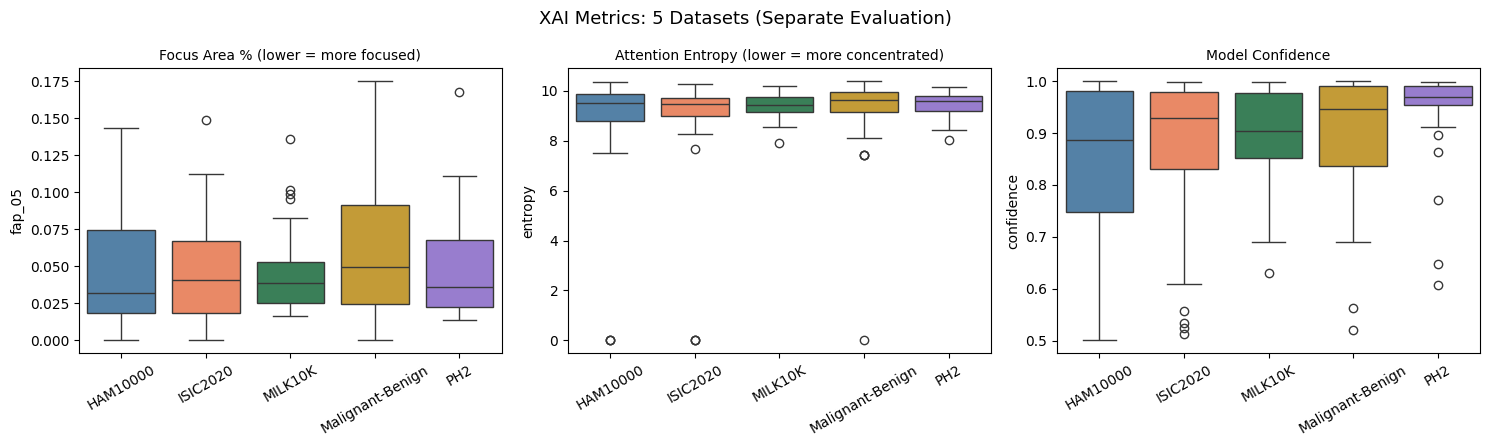


=== Mann-Whitney U (vs HAM10000) ===
  fap_05: HAM10000=0.0480 vs ISIC2020=0.0462  p=0.8999 significant=no
  fap_05: HAM10000=0.0480 vs MILK10K=0.0480  p=0.3041 significant=no
  fap_05: HAM10000=0.0480 vs Malignant-Benign=0.0607  p=0.1857 significant=no
  fap_05: HAM10000=0.0480 vs PH2=0.0479  p=0.5894 significant=no
  entropy: HAM10000=8.4948 vs ISIC2020=8.4554  p=0.6572 significant=no
  entropy: HAM10000=8.4948 vs MILK10K=9.4242  p=0.8766 significant=no
  entropy: HAM10000=8.4948 vs Malignant-Benign=9.0623  p=0.6151 significant=no
  entropy: HAM10000=8.4948 vs PH2=9.4776  p=0.6520 significant=no


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
order = list(all_results.keys())
pal = ["steelblue", "coral", "seagreen", "goldenrod", "mediumpurple"]

metrics = ["fap_05", "entropy", "confidence"]
titles  = [
    "Focus Area % (lower = more focused)",
    "Attention Entropy (lower = more concentrated)",
    "Model Confidence"
]

for ax, metric, title in zip(axes, metrics, titles):
    sns.boxplot(data=xai_df, x="dataset", y=metric, order=order,
                palette=pal, ax=ax)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("XAI Metrics: 5 Datasets (Separate Evaluation)", fontsize=13)
plt.tight_layout()
plt.savefig(OUT / "figures" / "RQ6_ext_xai_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

# Statistical test vs HAM10000
from scipy.stats import mannwhitneyu
ham_xai = xai_df[xai_df["dataset"] == "HAM10000"]
print("\n=== Mann-Whitney U (vs HAM10000) ===")
for m in ["fap_05", "entropy"]:
    for ds in all_results.keys():
        if ds == "HAM10000":
            continue
        ext_vals = xai_df[xai_df["dataset"] == ds][m]
        if len(ext_vals) > 2:
            _, p = mannwhitneyu(ham_xai[m], ext_vals)
            sig = "yes" if p < 0.05 else "no"
            print(f"  {m}: HAM10000={ham_xai[m].mean():.4f} vs {ds}={ext_vals.mean():.4f}  p={p:.4f} significant={sig}")

---

## CELL 9: MILK10K Modality Analysis

MILK10K has two image types: **dermoscopic** and **clinical: close-up**.
Test whether attention quality differs between modalities.

---

## CELL 10: Inter-Method Disagreement Per Dataset

In [ ]:
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, EigenCAM, LayerCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

cam_methods = {
    "GradCAM": lambda m, tl: GradCAM(model=m, target_layers=[tl]),
    "GradCAM++": lambda m, tl: GradCAMPlusPlus(model=m, target_layers=[tl]),
    "EigenCAM": lambda m, tl: EigenCAM(model=m, target_layers=[tl]),
    "LayerCAM": lambda m, tl: LayerCAM(model=m, target_layers=[tl]),
}

def jaccard(a, b, t=0.5):
    a_bin = (a >= t).astype(float)
    b_bin = (b >= t).astype(float)
    intersect = np.sum(np.minimum(a_bin, b_bin))
    union = np.sum(np.maximum(a_bin, b_bin))
    return intersect / (union + 1e-8)

disc_rows = []
for name, res in all_results.items():
    sample = res.sample(min(20, len(res)), random_state=42)
    for _, row in tqdm(sample.iterrows(), total=len(sample), desc=f"Disagreement {name}", leave=False):
        try:
            img = np.array(Image.open(row["filepath"]).convert("RGB").resize((224, 224)))
            inp = transform(image=img)["image"].unsqueeze(0).to(device)
            with torch.no_grad():
                _ = torch.sigmoid(model(inp)[0, 0]).item()
            
            cams = {}
            for mname, factory in cam_methods.items():
                with factory(model, target_layer) as cg:
                    cams[mname] = cg(input_tensor=inp, targets=[ClassifierOutputTarget(0)])[0]
            
            jac_vals = []
            method_names = list(cams.keys())
            for i in range(len(method_names)):
                for j in range(i + 1, len(method_names)):
                    jac_vals.append(jaccard(cams[method_names[i]], cams[method_names[j]]))
            
            disc_rows.append({
                "dataset": name,
                "image_id": row["image_id"],
                "correct": row["correct"],
                "avg_jaccard": np.mean(jac_vals),
                "min_jaccard": np.min(jac_vals),
                "max_jaccard": np.max(jac_vals),
            })
        except Exception as e:
            print(f"  ERROR on {row['image_id']}: {e}")

disc_df = pd.DataFrame(disc_rows)
print(f"\nInter-method disagreement computed for {len(disc_df)} images")
print("\n=== Jaccard by Dataset ===")
print(disc_df.groupby("dataset")[["avg_jaccard", "min_jaccard", "correct"]].agg(["mean", "std"]).round(4))


Inter-method disagreement computed for 100 images

=== Jaccard by Dataset ===
                 avg_jaccard         min_jaccard         correct        
                        mean     std        mean     std    mean     std
dataset                                                                 
HAM10000              0.4294  0.2086      0.1465  0.2537    0.75  0.4443
ISIC2020              0.3827  0.1220      0.0532  0.1344    0.95  0.2236
MILK10K               0.3717  0.1188      0.0375  0.1217    0.30  0.4702
Malignant-Benign      0.5063  0.2029      0.2046  0.3201    0.70  0.4702
PH2                   0.4065  0.1326      0.0537  0.1710    0.55  0.5104


In [ ]:
# Save all results. Inter-method disagreement is optional and may be generated later.
perf_df.to_csv(OUT / "metrics" / "RQ6_ext_separate_performance.csv", index=False)
xai_df.to_csv(OUT / "metrics" / "RQ6_ext_xai_all_datasets.csv", index=False)

if "disc_df" in globals() and isinstance(disc_df, pd.DataFrame) and len(disc_df) > 0:
    disc_df.to_csv(OUT / "metrics" / "RQ6_ext_disagreement_all_datasets.csv", index=False)
    print(f"  {OUT}/metrics/RQ6_ext_disagreement_all_datasets.csv")
else:
    disc_df = pd.DataFrame(columns=["dataset", "image_id", "correct", "avg_jaccard", "min_jaccard", "max_jaccard"])
    print("  Skipped RQ6_ext_disagreement_all_datasets.csv because inter-method disagreement has not been computed yet.")

# Save combined scenario results
combined_top3_df.to_csv(OUT / "metrics" / "RQ6_ext_combined_top3.csv", index=False)
combined_dermoscopic_df.to_csv(OUT / "metrics" / "RQ6_ext_combined_dermoscopic.csv", index=False)
combined_all5_df.to_csv(OUT / "metrics" / "RQ6_ext_combined_all5.csv", index=False)

print("Saved:")
print(f"  {OUT}/metrics/RQ6_ext_separate_performance.csv")
print(f"  {OUT}/metrics/RQ6_ext_xai_all_datasets.csv")
print(f"  {OUT}/metrics/RQ6_ext_combined_top3.csv")
print(f"  {OUT}/metrics/RQ6_ext_combined_dermoscopic.csv")
print(f"  {OUT}/metrics/RQ6_ext_combined_all5.csv")

  C:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_XAI_research\notebooks\outputs/metrics/RQ6_ext_disagreement_all_datasets.csv
Saved:
  C:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_XAI_research\notebooks\outputs/metrics/RQ6_ext_separate_performance.csv
  C:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_XAI_research\notebooks\outputs/metrics/RQ6_ext_xai_all_datasets.csv
  C:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_XAI_research\notebooks\outputs/metrics/RQ6_ext_combined_top3.csv
  C:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_XAI_research\notebooks\outputs/metrics/RQ6_ext_combined_dermoscopic.csv
  C:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_XAI_research\notebooks\outputs/metrics/RQ6_ext_combined_all5.csv


In [ ]:
if "disc_df" not in globals():
    disc_df = pd.DataFrame(columns=["dataset", "image_id", "correct", "avg_jaccard", "min_jaccard", "max_jaccard"])
    print("Inter-method disagreement has not been computed yet; skipping Jaccard summary.")

print("\n" + "=" * 80)
print("RQ6 EXTENDED SUMMARY — SEPARATE + COMBINED EVALUATION")
print("=" * 80)

print("\n--- TABLE 1: Within-Dataset Evaluation ---")
print(f"{'Dataset':<25} {'N':>6} {'AUC':>8} {'Acc':>8} {'Conf':>8} {'AUC Drop':>10} {'XAI FAP':>10}")
print("-" * 80)
for name, res in all_results.items():
    auc = roc_auc_score(res["true_label"], res["malignant_prob"]) if res["true_label"].nunique() > 1 else float("nan")
    acc = accuracy_score(res["true_label"], res["pred"])
    conf = res["confidence"].mean()
    drop = ham_auc - auc if not np.isnan(auc) else float("nan")
    xai_sub = xai_df[xai_df["dataset"] == name]
    fap_val = xai_sub["fap_05"].mean() if len(xai_sub) > 0 else float("nan")
    print(f"{name:<25} {len(res):>6} {auc:>8.4f} {acc:>8.4f} {conf:>8.4f} {drop:>+10.4f} {fap_val:>10.4f}")

print("\n--- COMBINED SCENARIOS ---")
print(f"  Top-3 (ISIC+HAM+MILK):  N={len(combined_top3_df):>5}  AUC={top3_auc:.4f}  Acc={top3_acc:.4f}  Conf={top3_conf:.4f}")
print(f"  Dermoscopy-Only (HAM+ISIC+PH2): N={len(combined_dermoscopic_df):>5}  AUC={dermoscopic_auc:.4f}  Acc={dermoscopic_acc:.4f}  Conf={dermoscopic_conf:.4f}")
print(f"  All-5 Combined:        N={len(combined_all5_df):>5}  AUC={all5_auc:.4f}  Acc={all5_acc:.4f}  Conf={all5_conf:.4f}")
print(f"\n  AUC drop from HAM10000:")
print(f"    Top-3:         {ham_auc - top3_auc:+.4f}")
print(f"    Dermoscopy-Only: {ham_auc - dermoscopic_auc:+.4f}")
print(f"    All-5:        {ham_auc - all5_auc:+.4f}")

print("\n--- XAI Metrics (mean) ---")
for ds in all_results.keys():
    sub = xai_df[xai_df["dataset"] == ds]
    if len(sub) > 0:
        print(f"  {ds:<20}: FAP={sub['fap_05'].mean():.4f}  Entropy={sub['entropy'].mean():.4f}  Correct%={sub['correct'].mean():.4f}")

print("\n--- Inter-Method Disagreement (Jaccard) ---")
for ds in all_results.keys():
    sub = disc_df[disc_df["dataset"] == ds]
    if len(sub) > 0:
        print(f"  {ds:<20}: Jaccard={sub['avg_jaccard'].mean():.4f}  Correct%={sub['correct'].mean():.4f}")

print("\n" + "=" * 80)
print("KEY FINDINGS:")
for name, res in all_results.items():
    if name == "HAM10000":
        continue
    auc = roc_auc_score(res["true_label"], res["malignant_prob"]) if res["true_label"].nunique() > 1 else float("nan")
    drop = ham_auc - auc
    xai_sub = xai_df[xai_df["dataset"] == name]
    fap_v = xai_sub["fap_05"].mean() if len(xai_sub) > 0 else float("nan")
    ham_fap = xai_df[xai_df["dataset"] == "HAM10000"]["fap_05"].mean()
    disc_sub = disc_df[disc_df["dataset"] == name]
    disc_v = disc_sub["avg_jaccard"].mean() if len(disc_sub) > 0 else float("nan")
    ham_disc = disc_df[disc_df["dataset"] == "HAM10000"]["avg_jaccard"].mean()
    print(f"\n[{name}]")
    if drop > 0.10: print(f"  ❌ Large AUC drop {drop:+.3f}")
    elif drop > 0.05: print(f"  ⚠️  Moderate AUC drop {drop:+.3f}")
    else: print(f"  ✅ Minimal AUC drop {drop:+.3f}")
    if fap_v > ham_fap + 0.02: print(f"  📍 Attention MORE diffuse (FAP {fap_v:.3f} vs HAM10000 {ham_fap:.3f})")
    else: print(f"  📍 Attention similar to HAM10000 (FAP {fap_v:.3f})")
    if disc_v < ham_disc - 0.03: print(f"  ⚠️  Higher disagreement (Jaccard {disc_v:.3f} vs {ham_disc:.3f}) — possible OOD signal")
    else: print(f"  ✅ Agreement similar to HAM10000 (Jaccard {disc_v:.3f})")

print("=" * 80)


RQ6 EXTENDED SUMMARY — SEPARATE + COMBINED EVALUATION

--- TABLE 1: Within-Dataset Evaluation ---
Dataset                        N      AUC      Acc     Conf   AUC Drop    XAI FAP
--------------------------------------------------------------------------------
HAM10000                   10015   0.9478   0.8698   0.8963    +0.0000     0.0480
ISIC2020                   31126   0.6369   0.9127   0.8937    +0.3108     0.0462
MILK10K                     8234   0.6665   0.4183   0.8622    +0.2813     0.0480
Malignant-Benign           33992   0.7803   0.6489   0.8656    +0.1674     0.0607
PH2                          200   0.7450   0.5150   0.9266    +0.2028     0.0479

--- COMBINED SCENARIOS ---
  Top-3 (ISIC+HAM+MILK):  N=49375  AUC=0.7125  Acc=0.8216  Conf=0.8890
  Dermoscopy-Only (HAM+ISIC+PH2): N=41341  AUC=0.8627  Acc=0.9004  Conf=0.8945
  All-5 Combined:        N=83567  AUC=0.7456  Acc=0.7506  Conf=0.8796

  AUC drop from HAM10000:
    Top-3:         +0.2353
    Dermoscopy-Only: +0.08

---

---

## CELL 11: Final Summary Table

---

In [ ]:
if "disc_df" not in globals():
    disc_df = pd.DataFrame(columns=["dataset", "image_id", "correct", "avg_jaccard", "min_jaccard", "max_jaccard"])
    print("Inter-method disagreement has not been computed yet; skipping Jaccard summary.")

print("\n" + "=" * 80)
print("RQ6 EXTENDED SUMMARY — SEPARATE + COMBINED EVALUATION")
print("=" * 80)

print("\n--- TABLE 1: Within-Dataset Evaluation ---")
print(f"{'Dataset':<22} {'N':>6} {'AUC':>8} {'Acc':>8} {'Conf':>8} {'AUC Drop':>10} {'Benign':>8} {'Mal':>8}")
print("-" * 80)
for name, res in all_results.items():
    auc = roc_auc_score(res["true_label"], res["malignant_prob"]) if res["true_label"].nunique() > 1 else float("nan")
    acc = accuracy_score(res["true_label"], res["pred"])
    conf = res["confidence"].mean()
    drop = ham_auc - auc if not np.isnan(auc) else float("nan")
    benign_sub = res[res["true_label"] == 0]
    mal_sub = res[res["true_label"] == 1]
    benign_acc = accuracy_score(benign_sub["true_label"], benign_sub["pred"]) if len(benign_sub) > 0 else float("nan")
    mal_acc = accuracy_score(mal_sub["true_label"], mal_sub["pred"]) if len(mal_sub) > 0 else float("nan")
    xai_sub = xai_df[xai_df["dataset"] == name]
    fap_val = xai_sub["fap_05"].mean() if len(xai_sub) > 0 else float("nan")
    print(f"{name:<22} {len(res):>6} {auc:>8.4f} {acc:>8.4f} {conf:>8.4f} {drop:>+10.4f} {benign_acc:>8.4f} {mal_acc:>8.4f}")

print("\n--- COMBINED SCENARIOS ---")
for label, df, auc_val, acc_val, conf_val in [
    ("Top-3 (ISIC+HAM+MILK)", combined_top3_df, top3_auc, top3_acc, top3_conf),
    ("Dermoscopy-Only (HAM+ISIC+PH2)", combined_dermoscopic_df, dermoscopic_auc, dermoscopic_acc, dermoscopic_conf),
    ("All-5 Combined", combined_all5_df, all5_auc, all5_acc, all5_conf),
]:
    benign_sub = df[df["true_label"] == 0]
    mal_sub = df[df["true_label"] == 1]
    ben_acc = accuracy_score(benign_sub["true_label"], benign_sub["pred"]) if len(benign_sub) > 0 else float("nan")
    mal_acc2 = accuracy_score(mal_sub["true_label"], mal_sub["pred"]) if len(mal_sub) > 0 else float("nan")
    print(f"  {label}: N={len(df):>5} AUC={auc_val:.4f} Acc={acc_val:.4f} Conf={conf_val:.4f} | Benign={ben_acc:.4f} Mal={mal_acc2:.4f}")
    print(f"    AUC drop from HAM10000: {ham_auc - auc_val:+.4f}")

print("\n--- XAI Metrics (mean) ---")
for ds in all_results.keys():
    sub = xai_df[xai_df["dataset"] == ds]
    if len(sub) > 0:
        print(f"  {ds:<22}: FAP={sub['fap_05'].mean():.4f}  Entropy={sub['entropy'].mean():.4f}  Correct%={sub['correct'].mean():.4f}")

print("\n--- Inter-Method Disagreement (Jaccard) ---")
for ds in all_results.keys():
    sub = disc_df[disc_df["dataset"] == ds]
    if len(sub) > 0:
        print(f"  {ds:<22}: Jaccard={sub['avg_jaccard'].mean():.4f}  Correct%={sub['correct'].mean():.4f}")

print("\n" + "=" * 80)
print("KEY FINDINGS:")
for name, res in all_results.items():
    if name == "HAM10000":
        continue
    auc = roc_auc_score(res["true_label"], res["malignant_prob"]) if res["true_label"].nunique() > 1 else float("nan")
    drop = ham_auc - auc
    xai_sub = xai_df[xai_df["dataset"] == name]
    fap_v = xai_sub["fap_05"].mean() if len(xai_sub) > 0 else float("nan")
    ham_fap = xai_df[xai_df["dataset"] == "HAM10000"]["fap_05"].mean()
    disc_sub = disc_df[disc_df["dataset"] == name]
    disc_v = disc_sub["avg_jaccard"].mean() if len(disc_sub) > 0 else float("nan")
    ham_disc = disc_df[disc_df["dataset"] == "HAM10000"]["avg_jaccard"].mean()
    benign_sub = res[res["true_label"] == 0]
    mal_sub = res[res["true_label"] == 1]
    ben_acc_val = accuracy_score(benign_sub["true_label"], benign_sub["pred"]) if len(benign_sub) > 0 else float("nan")
    mal_acc_val = accuracy_score(mal_sub["true_label"], mal_sub["pred"]) if len(mal_sub) > 0 else float("nan")
    print(f"\n[{name}]")
    if drop > 0.10: print(f"  ❌ Large AUC drop {drop:+.3f}")
    elif drop > 0.05: print(f"  ⚠️  Moderate AUC drop {drop:+.3f}")
    else: print(f"  ✅ Minimal AUC drop {drop:+.3f}")
    print(f"  Benign accuracy: {ben_acc_val:.4f}  Malignant accuracy: {mal_acc_val:.4f}")
    if fap_v > ham_fap + 0.02: print(f"  📍 Attention MORE diffuse (FAP {fap_v:.3f} vs HAM10000 {ham_fap:.3f})")
    else: print(f"  📍 Attention similar to HAM10000 (FAP {fap_v:.3f})")
    if disc_v < ham_disc - 0.03: print(f"  ⚠️  Higher disagreement (Jaccard {disc_v:.3f} vs {ham_disc:.3f}) — possible OOD signal")
    else: print(f"  ✅ Agreement similar to HAM10000 (Jaccard {disc_v:.3f})")

print("=" * 80)


RQ6 EXTENDED SUMMARY — SEPARATE + COMBINED EVALUATION

--- TABLE 1: Within-Dataset Evaluation ---
Dataset                     N      AUC      Acc     Conf   AUC Drop   Benign      Mal
--------------------------------------------------------------------------------
HAM10000                10015   0.9478   0.8698   0.8963    +0.0000   0.8675   0.8814
ISIC2020                31126   0.6369   0.9127   0.8937    +0.3108   0.9246   0.2514
MILK10K                  8234   0.6665   0.4183   0.8622    +0.2813   0.9212   0.2131
Malignant-Benign        33992   0.7803   0.6489   0.8656    +0.1674   0.9272   0.3705
PH2                       200   0.7450   0.5150   0.9266    +0.2028   0.9875   0.2000

--- COMBINED SCENARIOS ---
  Top-3 (ISIC+HAM+MILK): N=49375 AUC=0.7125 Acc=0.8216 Conf=0.8890 | Benign=0.9128 Mal=0.3512
    AUC drop from HAM10000: +0.2353
  Dermoscopy-Only (HAM+ISIC+PH2): N=41341 AUC=0.8627 Acc=0.9004 Conf=0.8945 | Benign=0.9125 Mal=0.6951
    AUC drop from HAM10000: +0.0851
  All-5